# Native CatBoost Tuning

This notebook tunes CatBoost specifically, using its native handling of categorical columns (rather than the ordinal-encoded version from the last notebook), and compares four different depth/regularization configurations using the same nested five-fold approach.


## Import libraries


In [4]:
from pathlib import Path
import gc
import json
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
print("Libraries imported successfully.")

Libraries imported successfully.


## Set paths and experiment settings


In [6]:
current_folder = Path.cwd().resolve()
project_root = current_folder.parent if current_folder.name == "notebooks" else current_folder
dataset_path = project_root / "data" / "modeling" / "final_feature_dataset.pkl"
training_ids_path = project_root / "data" / "modeling" / "splits" / "training_ids.csv"
test_ids_path = project_root / "data" / "modeling" / "splits" / "test_ids.csv"
folds_path = project_root / "data" / "modeling" / "splits" / "training_fold_assignments.csv"
previous_boosted_path = project_root / "data" / "modeling" / "boosted_results" / "boosted_oof_predictions.pkl"
result_folder = project_root / "data" / "modeling" / "catboost_tuning_results"
figure_folder = project_root / "reports" / "figures"
audit_folder = project_root / "reports" / "audits"
for folder in [result_folder, figure_folder, audit_folder]:
    folder.mkdir(parents=True, exist_ok=True)
for path in [dataset_path, training_ids_path, test_ids_path, folds_path]:
    assert path.exists(), f"Required file missing: {path}"
RANDOM_STATE = 2026
EXPECTED_TRAINING_ROWS = 246008
MAX_ITERATIONS = 5000
EARLY_STOPPING_ROUNDS = 200
print("Maximum iterations:", MAX_ITERATIONS)

Maximum iterations: 5000


## Load the complete training dataset


In [8]:
full_data = pd.read_pickle(dataset_path)
training_ids = pd.read_csv(training_ids_path)["SK_ID_CURR"]
test_ids = pd.read_csv(test_ids_path)["SK_ID_CURR"]
fold_assignments = pd.read_csv(folds_path)
training_id_set = set(training_ids)
test_id_set = set(test_ids)
training_data = full_data.loc[full_data["SK_ID_CURR"].isin(training_id_set)].copy()
training_data = training_data.merge(fold_assignments, on="SK_ID_CURR", how="left", validate="one_to_one")
assert len(training_data) == EXPECTED_TRAINING_ROWS
assert training_data["FOLD"].nunique() == 5
assert not training_data["SK_ID_CURR"].isin(test_id_set).any()
print("Training rows:", len(training_data))
print("Final test excluded:", len(test_ids))
print("Default rate:", round(training_data["TARGET"].mean(), 5))

Training rows: 246008
Final test excluded: 61503
Default rate: 0.08073


Same training data and folds as before.


## Prepare native CatBoost predictors


In [11]:
excluded_columns = ["SK_ID_CURR", "TARGET", "FOLD", "CODE_GENDER"]
predictor_columns = [c for c in training_data.columns if c not in excluded_columns]
categorical_columns = training_data[predictor_columns].select_dtypes(exclude="number").columns.tolist()
numerical_columns = [c for c in predictor_columns if c not in categorical_columns]
X = training_data[predictor_columns].copy()
y = training_data["TARGET"].astype("int8").copy()
folds = training_data["FOLD"].astype(int).copy()
for column in categorical_columns:
    X[column] = X[column].fillna("Unknown").astype(str)
print("Predictors used:", len(predictor_columns))
print("Native numerical predictors:", len(numerical_columns))
print("Native categorical predictors:", len(categorical_columns))
print("Remaining numerical missing cells handled natively:", int(X[numerical_columns].isna().sum().sum()))

Predictors used: 330
Native numerical predictors: 318
Native categorical predictors: 12
Remaining numerical missing cells handled natively: 1918164


Categorical columns are kept as text here (filled with "Unknown" for missing values) instead of being encoded, since CatBoost can work with categories directly rather than needing them converted to numbers first.


## Define the tuning configurations


In [14]:
candidate_configurations = {
    "native_depth6": {
        "depth": 6, "learning_rate": 0.03, "l2_leaf_reg": 7.0,
        "random_strength": 0.5, "bagging_temperature": 1.0, "rsm": 0.90,
    },
    "native_depth7": {
        "depth": 7, "learning_rate": 0.03, "l2_leaf_reg": 5.0,
        "random_strength": 1.0, "bagging_temperature": 1.0, "rsm": 0.90,
    },
    "native_depth8": {
        "depth": 8, "learning_rate": 0.025, "l2_leaf_reg": 8.0,
        "random_strength": 1.0, "bagging_temperature": 1.0, "rsm": 0.90,
    },
    "native_depth7_regularized": {
        "depth": 7, "learning_rate": 0.025, "l2_leaf_reg": 12.0,
        "random_strength": 0.5, "bagging_temperature": 0.5, "rsm": 1.0,
    },
}
configuration_table = pd.DataFrame(candidate_configurations).T.reset_index().rename(columns={"index": "configuration"})
configuration_table

,configuration,depth,learning_rate,l2_leaf_reg,random_strength,bagging_temperature,rsm
0,native_depth6,6.0,0.030,7.0,0.5,1.0,0.9
1,native_depth7,7.0,0.030,5.0,1.0,1.0,0.9
2,native_depth8,8.0,0.025,8.0,1.0,1.0,0.9
3,native_depth7_regularized,7.0,0.025,12.0,0.5,0.5,1.0


Four configurations to compare, mostly varying tree depth and regularization strength, to see which setup works best for this data.


## Model and metric functions


In [17]:
def build_catboost(configuration, iterations):
    return CatBoostClassifier(
        iterations=iterations,
        depth=configuration["depth"],
        learning_rate=configuration["learning_rate"],
        l2_leaf_reg=configuration["l2_leaf_reg"],
        random_strength=configuration["random_strength"],
        bagging_temperature=configuration["bagging_temperature"],
        rsm=configuration["rsm"],
        loss_function="Logloss", eval_metric="AUC",
        bootstrap_type="Bayesian", one_hot_max_size=10,
        random_seed=RANDOM_STATE, thread_count=-1,
        allow_writing_files=False, verbose=False,
    )

def calculate_metrics(y_true, probability):
    return {
        "roc_auc": roc_auc_score(y_true, probability),
        "pr_auc": average_precision_score(y_true, probability),
    }
print("Functions created.")

Functions created.


Builds a CatBoost model from one of the four candidate settings, and reuses the same ROC-AUC/PR-AUC scoring as before.


## Run full five-fold tuning


In [20]:
oof_predictions = pd.DataFrame({
    "SK_ID_CURR": training_data["SK_ID_CURR"].to_numpy(),
    "TARGET": y.to_numpy(),
    "FOLD": folds.to_numpy(),
})
fold_rows = []
iteration_rows = []

for configuration_name, configuration in candidate_configurations.items():
    print(f"\nCONFIGURATION: {configuration_name}")
    configuration_oof = np.full(len(X), np.nan, dtype="float64")
    for fold_number in sorted(folds.unique()):
        outer_train_mask = folds.ne(fold_number)
        outer_valid_mask = folds.eq(fold_number)
        outer_train_indices = np.flatnonzero(outer_train_mask.to_numpy())
        outer_valid_indices = np.flatnonzero(outer_valid_mask.to_numpy())
        inner_train_indices, inner_valid_indices = train_test_split(
            outer_train_indices, test_size=0.10, stratify=y.iloc[outer_train_indices],
            random_state=RANDOM_STATE + int(fold_number)
        )

        search_model = build_catboost(configuration, MAX_ITERATIONS)
        search_model.fit(
            X.iloc[inner_train_indices], y.iloc[inner_train_indices],
            cat_features=categorical_columns,
            eval_set=(X.iloc[inner_valid_indices], y.iloc[inner_valid_indices]),
            early_stopping_rounds=EARLY_STOPPING_ROUNDS, verbose=False
        )
        selected_iterations = int(search_model.get_best_iteration()) + 1
        assert 1 <= selected_iterations <= MAX_ITERATIONS
        del search_model
        gc.collect()

        final_model = build_catboost(configuration, selected_iterations)
        start_time = time.time()
        final_model.fit(
            X.iloc[outer_train_indices], y.iloc[outer_train_indices],
            cat_features=categorical_columns, verbose=False
        )
        probability = final_model.predict_proba(X.iloc[outer_valid_indices])[:, 1]
        elapsed_minutes = (time.time() - start_time) / 60
        configuration_oof[outer_valid_indices] = probability
        metrics = calculate_metrics(y.iloc[outer_valid_indices], probability)
        metrics.update({
            "configuration": configuration_name, "fold": int(fold_number),
            "selected_iterations": selected_iterations,
            "outer_train_rows": len(outer_train_indices),
            "outer_validation_rows": len(outer_valid_indices),
            "refit_minutes": elapsed_minutes,
        })
        fold_rows.append(metrics)
        iteration_rows.append({
            "configuration": configuration_name, "fold": int(fold_number),
            "selected_iterations": selected_iterations
        })
        print(
            f"  Fold {fold_number}: iterations={selected_iterations}, "
            f"AUC={metrics['roc_auc']:.5f}, PR AUC={metrics['pr_auc']:.5f}, "
            f"minutes={elapsed_minutes:.2f}"
        )
        del final_model, probability
        gc.collect()

    assert not np.isnan(configuration_oof).any()
    oof_predictions[configuration_name] = configuration_oof

fold_metrics = pd.DataFrame(fold_rows)
selected_iterations = pd.DataFrame(iteration_rows)
print("\nAll CatBoost tuning fits completed.")


CONFIGURATION: native_depth6
  Fold 1: iterations=3987, AUC=0.79006, PR AUC=0.28333, minutes=6.35
  Fold 2: iterations=4212, AUC=0.78929, PR AUC=0.28554, minutes=7.30
  Fold 3: iterations=4203, AUC=0.78494, PR AUC=0.28063, minutes=8.14
  Fold 4: iterations=3673, AUC=0.78905, PR AUC=0.27544, minutes=6.18
  Fold 5: iterations=3646, AUC=0.79008, PR AUC=0.28798, minutes=5.85

CONFIGURATION: native_depth7
  Fold 1: iterations=3054, AUC=0.78911, PR AUC=0.28158, minutes=5.71
  Fold 2: iterations=2797, AUC=0.79023, PR AUC=0.28363, minutes=5.27
  Fold 3: iterations=3094, AUC=0.78411, PR AUC=0.27798, minutes=6.12
  Fold 4: iterations=1813, AUC=0.78757, PR AUC=0.27536, minutes=3.33
  Fold 5: iterations=2455, AUC=0.78883, PR AUC=0.28545, minutes=4.49

CONFIGURATION: native_depth8
  Fold 1: iterations=2513, AUC=0.78865, PR AUC=0.28265, minutes=5.55
  Fold 2: iterations=3245, AUC=0.79062, PR AUC=0.28388, minutes=6.96
  Fold 3: iterations=2108, AUC=0.78259, PR AUC=0.27746, minutes=4.58
  Fold 4: ite

Same nested approach as before, an inner split decides the number of iterations for each outer fold, then the model refits on the full outer-training data with that count.


## Compare complete OOF performance


In [23]:
overall_rows = []
for configuration_name in candidate_configurations:
    metrics = calculate_metrics(oof_predictions["TARGET"], oof_predictions[configuration_name])
    config_folds = fold_metrics.loc[fold_metrics["configuration"].eq(configuration_name)]
    metrics.update({
        "configuration": configuration_name,
        "fold_auc_mean": config_folds["roc_auc"].mean(),
        "fold_auc_std": config_folds["roc_auc"].std(),
        "mean_selected_iterations": config_folds["selected_iterations"].mean(),
        "total_refit_minutes": config_folds["refit_minutes"].sum(),
    })
    overall_rows.append(metrics)
overall_metrics = pd.DataFrame(overall_rows).sort_values(
    ["roc_auc", "pr_auc"], ascending=False
).reset_index(drop=True)
best_configuration_name = overall_metrics.iloc[0]["configuration"]
best_configuration = candidate_configurations[best_configuration_name]
overall_metrics.round(6)

,roc_auc,pr_auc,configuration,fold_auc_mean,fold_auc_std,mean_selected_iterations,total_refit_minutes
0,0.788938,0.282501,native_depth7_regularized,0.788953,0.002848,3009.4,27.072341
1,0.788668,0.282128,native_depth6,0.788684,0.002143,3944.2,33.820716
2,0.787956,0.280667,native_depth8,0.787952,0.003182,2619.8,28.910336
3,0.787941,0.280401,native_depth7,0.787970,0.002357,2642.6,24.918688


The regularized depth-7 setup comes out on top, though all four configurations are close. This is the one that gets carried forward.


## Compare with the earlier CatBoost model


In [26]:
comparison_rows = overall_metrics[
    ["configuration", "roc_auc", "pr_auc"]
].copy()
if previous_boosted_path.exists():
    previous_oof = pd.read_pickle(previous_boosted_path)
    if "catboost" in previous_oof.columns:
        previous_metrics = calculate_metrics(previous_oof["TARGET"], previous_oof["catboost"])
        previous_metrics["configuration"] = "previous_ordinal_catboost"
        comparison_rows = pd.concat([comparison_rows, pd.DataFrame([previous_metrics])], ignore_index=True)
comparison_rows = comparison_rows.sort_values("roc_auc", ascending=False).reset_index(drop=True)
comparison_rows.round(6)

,configuration,roc_auc,pr_auc
0,native_depth7_regularized,0.788938,0.282501
1,native_depth6,0.788668,0.282128
2,native_depth8,0.787956,0.280667
3,native_depth7,0.787941,0.280401
4,previous_ordinal_catboost,0.787805,0.280249


The best native configuration here slightly beats the earlier ordinal-encoded CatBoost from the boosted-tree comparison notebook, so letting CatBoost handle categories natively does help a little.


## Plot tuned OOF curves


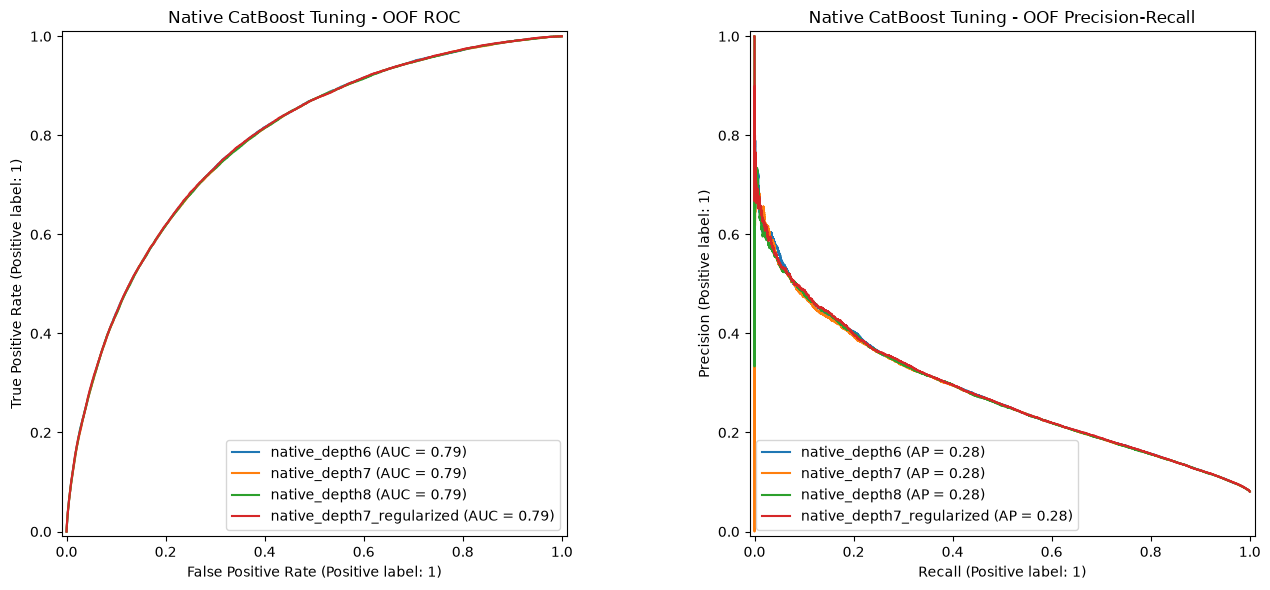

Figure saved: /Users/taranveersingh/A-MRP/reports/figures/native_catboost_tuning_oof_curves.png


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for configuration_name in candidate_configurations:
    RocCurveDisplay.from_predictions(oof_predictions["TARGET"], oof_predictions[configuration_name], name=configuration_name, ax=axes[0])
    PrecisionRecallDisplay.from_predictions(oof_predictions["TARGET"], oof_predictions[configuration_name], name=configuration_name, ax=axes[1])
axes[0].set_title("Native CatBoost Tuning - OOF ROC")
axes[1].set_title("Native CatBoost Tuning - OOF Precision-Recall")
fig.tight_layout()
figure_path = figure_folder / "native_catboost_tuning_oof_curves.png"
fig.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()
print("Figure saved:", figure_path)

Same idea as before, one curve per configuration tested.


## Validate and save outputs


In [32]:
validation_checks = pd.DataFrame([
    {"check": "Complete training dataset used", "passed": len(X) == EXPECTED_TRAINING_ROWS},
    {"check": "Every configuration used five folds", "passed": fold_metrics.groupby("configuration")["fold"].nunique().eq(5).all()},
    {"check": "All OOF predictions complete", "passed": not oof_predictions[list(candidate_configurations)].isna().any().any()},
    {"check": "One OOF row per training applicant", "passed": len(oof_predictions) == EXPECTED_TRAINING_ROWS and oof_predictions["SK_ID_CURR"].is_unique},
    {"check": "Final test excluded", "passed": not oof_predictions["SK_ID_CURR"].isin(test_id_set).any()},
    {"check": "Protected gender excluded", "passed": "CODE_GENDER" not in predictor_columns},
    {"check": "Native categorical features used", "passed": len(categorical_columns) > 0},
    {"check": "Selected iterations valid", "passed": selected_iterations["selected_iterations"].between(1, MAX_ITERATIONS).all()},
    {"check": "All outer rows used", "passed": fold_metrics["outer_train_rows"].add(fold_metrics["outer_validation_rows"]).eq(EXPECTED_TRAINING_ROWS).all()},
    {"check": "Metrics finite", "passed": np.isfinite(overall_metrics.select_dtypes(include="number").to_numpy()).all()},
])
assert validation_checks["passed"].all(), "At least one native CatBoost tuning check failed."
oof_predictions.to_pickle(result_folder / "native_catboost_oof_predictions.pkl")
oof_predictions.to_csv(result_folder / "native_catboost_oof_predictions.csv", index=False)
fold_metrics.to_csv(result_folder / "native_catboost_fold_metrics.csv", index=False)
overall_metrics.to_csv(result_folder / "native_catboost_overall_metrics.csv", index=False)
selected_iterations.to_csv(result_folder / "native_catboost_selected_iterations.csv", index=False)
configuration_table.to_csv(result_folder / "native_catboost_configurations.csv", index=False)
comparison_rows.to_csv(result_folder / "native_catboost_comparison.csv", index=False)
validation_checks.to_csv(audit_folder / "native_catboost_tuning_validation.csv", index=False)
with open(result_folder / "best_native_catboost_configuration.json", "w") as file:
    json.dump({"name": best_configuration_name, **best_configuration}, file, indent=2)
display(validation_checks)
print("Best configuration:", best_configuration_name)
print("Best native CatBoost OOF ROC AUC:", round(overall_metrics.iloc[0]["roc_auc"], 6))
print("Results saved in:", result_folder)
print("Final test evaluations performed: 0")

,check,passed
0,Complete training dataset used,True
1,Every configuration used five folds,True
2,All OOF predictions complete,True
3,One OOF row per training applicant,True
4,Final test excluded,True
5,Protected gender excluded,True
6,Native categorical features used,True
7,Selected iterations valid,True
8,All outer rows used,True
9,Metrics finite,True


Best configuration: native_depth7_regularized
Best native CatBoost OOF ROC AUC: 0.788938
Results saved in: /Users/taranveersingh/A-MRP/data/modeling/catboost_tuning_results
Final test evaluations performed: 0


All checks passed.


## Main results

The depth-7, more heavily regularized configuration came out on top (ROC-AUC 0.788938), a small improvement over the earlier ordinal-encoded CatBoost from the boosted-tree comparison notebook (0.787805). This confirms native categorical handling helps a little, and this configuration is the one carried forward into the final ensemble.
